# Clustering jerárquico
#### UD3. Aprendizaxe non supervisada
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo), Vanesa Resúa Eiras, Cristina Gómez Alonso

## 1. Definición

El clustering jerárquico implica la creación de grupos que tienen un orden predeterminado de arriba hacia abajo. Por ejemplo, todos los archivos y carpetas del disco duro están organizados en una jerarquía. Hay dos tipos de clustering jerárquico: divisivo y aglomerativo.

### Método divisivo (Top-down o de arriba hacia abajo)

En este método asignamos todas las observaciones (o instancias) a un solo clúster y luego dividimos el clúster en dos clústers más similares a nivel de grupo. Finalmente, procedemos recursivamente con cada clúster hasta que haya un clúster para cada observación.

### Método aglomerativo (Bottom-up o de abajo hacia arriba)

En este método asignamos cada observación (o instancia) a su propio cluster. Luego, calculamos la similitud (por ejemplo, la distancia euclídea) entre cada uno de los clústers y unimos los dos clústers más similares. Finalmente, se repiten los pasos 2 y 3 hasta que solo quede un único cluster.

## 2. Matriz de distancia o enlace

Antes de realizar el clustering, se requiere determinar la matriz de proximidad que contiene la distancia entre cada punto utilizando una función de distancia. Luego, la matriz se actualiza para mostrar la distancia entre cada cluster. Los siguientes tres métodos difieren en cómo se mide la distancia entre cada cluster.

### Enlace único o simple

En el clustering jerárquico de enlace único o simple, la distancia entre dos clústers se define como la mínima distancia entre dos puntos de cada cluster. Por ejemplo, la distancia entre los grupos "r" y "s" a la izquierda es igual a la longitud de la flecha entre los dos puntos más próximos.

<img src=img/Clustering_single.png>

### Enlace completo

En el clustering jerárquico de enlace completo, la distancia entre dos grupos se define como la distancia más larga entre dos puntos en cada cluster. Por ejemplo, la distancia entre los grupos "r" y "s" es igual a la longitud de la flecha entre los dos puntos más lejanos.
<img src=img/Clustering_complete.png>

### Enlace promedio

En el clustering jerárquico de enlace promedio, la distancia entre dos conglomerados se define como la distancia promedio entre cada punto de un clúster y cada punto del otro clúster. Por ejemplo, la distancia entre los grupos "r" y "s" es igual a la longitud promedio entre los puntos de conexión de uno y otro clúster.
<img src=img/Clustering_average.png>

|[Ejemplo del cálculo de una matriz de distancia de enlace simple (Simple Linkage)](https://people.revoledu.com/kardi/tutorial/Clustering/Numerical%20Example.htm)

## 3. Dendrogramas

Los [dendrogramas](https://en.wikipedia.org/wiki/Dendrogram) son diagramas de árbol que se utilizan con frecuencia para ilustrar la disposición de los clústers producidos por el clustering jerárquico. Los clados (o clústers hijos) se ordenan de acuerdo a cuán similares (o diferentes) son. Los clados que están cerca de la misma altura son similares entre sí; los clados con diferentes alturas son diferentes: cuanto mayor es la diferencia de altura, mayor es la diferencia.

A continuación se muestra un ejemplo relacionado con el conocido conjunto de datos Iris.

<img src=./img/Iris_dendrogram.png height='400px' width = '400px'>

## 4. Demo

Ahora vamos a realizar una demo de clustering jerárquico sobre un dataset de tendencias de compra en un centro comercial.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

### 4.1. Importación del dataset

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


### 4.2. EDA y Visual EDA

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


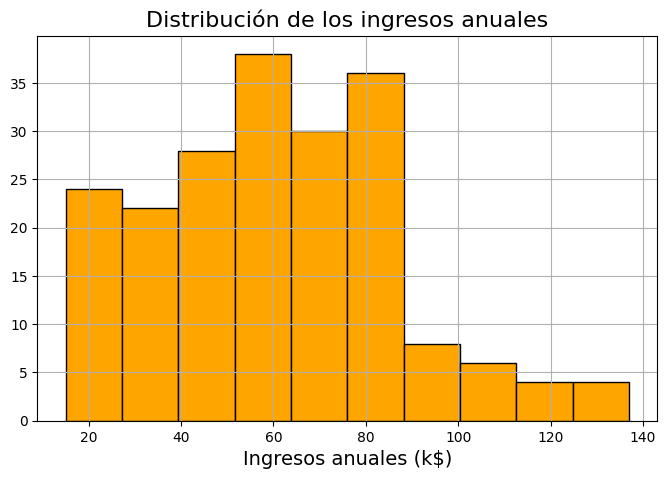

In [5]:
# Muestra mediante diagramas de barras la distribución de la la variable 'Ingresos Anuales (kEUR)'

plt.figure(figsize=(8,5))
plt.title("Distribución de los ingresos anuales",fontsize=16)
plt.xlabel ("Ingresos anuales (k$)",fontsize=14)
plt.grid(True)
plt.hist(df['Annual Income (k$)'],color='orange',edgecolor='k')
plt.show()

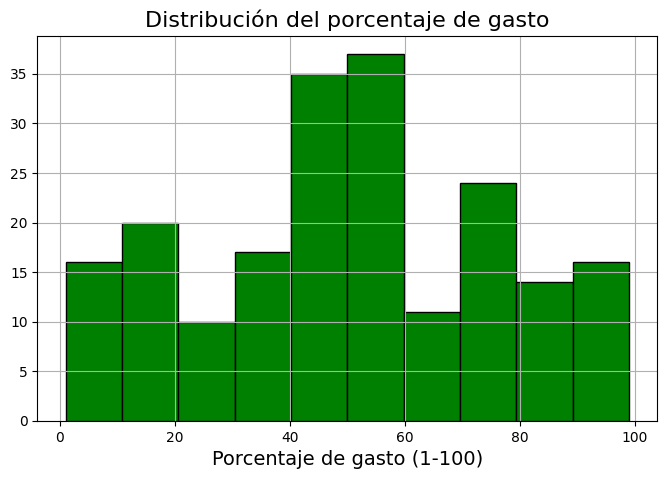

In [6]:
# Muestra mediante diagramas de barras la distribución de la la variable ‘Porcentaje_de_gasto’

plt.figure(figsize=(8,5))
plt.title("Distribución del porcentaje de gasto",fontsize=16)
plt.xlabel ("Porcentaje de gasto (1-100)",fontsize=14)
plt.grid(True)
plt.hist(df['Spending Score (1-100)'],color='green',edgecolor='k')
plt.show()

Entonces, ¿existe una correlación definitiva entre los ingresos anuales (annual income) y el porcentaje de gasto (spending score)? - *Aparentemente no*

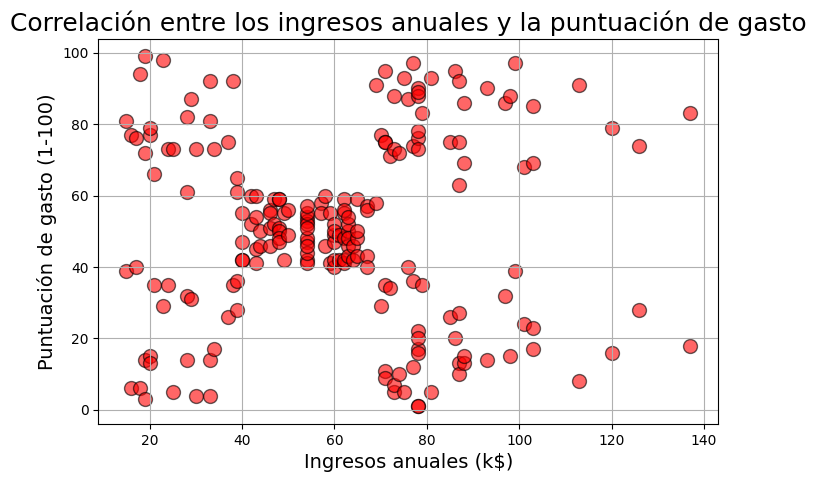

In [7]:
plt.figure(figsize=(8,5))
plt.title("Correlación entre los ingresos anuales y la puntuación de gasto",fontsize=18)
plt.xlabel ("Ingresos anuales (k$)",fontsize=14)
plt.ylabel ("Puntuación de gasto (1-100)",fontsize=14)
plt.grid(True)
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],color='red',edgecolor='k',alpha=0.6, s=100)
plt.show()

¿Existe una correlación entre la edad (age) y el porcentaje de gasto (spending score)? - *Aparentemente no*

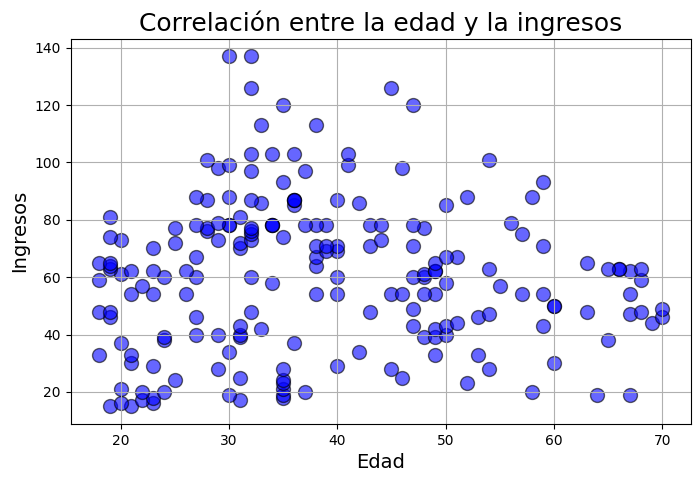

In [8]:
plt.figure(figsize=(8,5))
plt.title("Correlación entre la edad y la ingresos",fontsize=18)
plt.xlabel ("Edad",fontsize=14)
plt.ylabel ("Ingresos",fontsize=14)
plt.grid(True)
plt.scatter(df['Age'],df['Annual Income (k$)'],color='blue',edgecolor='k',alpha=0.6, s=100)
plt.show()

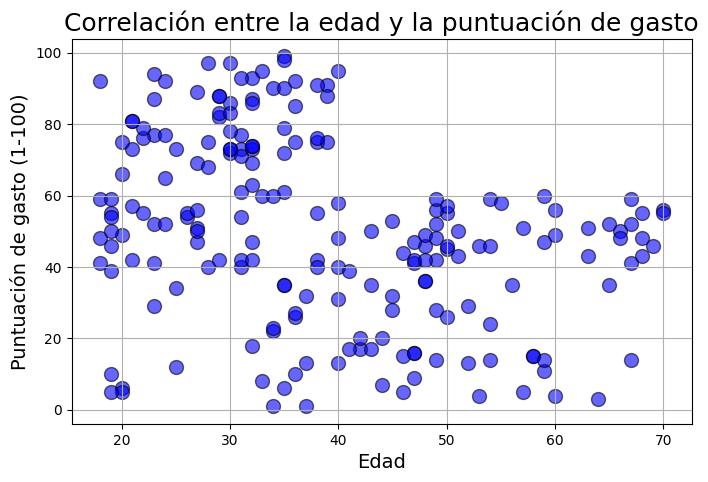

In [9]:
plt.figure(figsize=(8,5))
plt.title("Correlación entre la edad y la puntuación de gasto",fontsize=18)
plt.xlabel ("Edad",fontsize=14)
plt.ylabel ("Puntuación de gasto (1-100)",fontsize=14)
plt.grid(True)
plt.scatter(df['Age'],df['Spending Score (1-100)'],color='blue',edgecolor='k',alpha=0.6, s=100)
plt.show()

Propuesta: repite los dos gráficos anteriores, pero en esta ocasión cambiando el color de los círculos (markers), en función del sexo de la persona.

In [10]:
import seaborn as sns


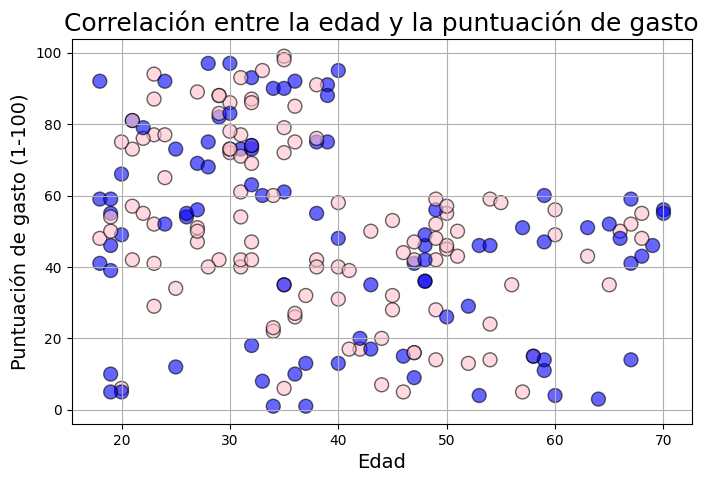

In [11]:
plt.figure(figsize=(8,5))
plt.title("Correlación entre la edad y la puntuación de gasto", fontsize=18)
plt.xlabel("Edad", fontsize=14)
plt.ylabel("Puntuación de gasto (1-100)", fontsize=14)
plt.grid(True)

colores = df['Gender'].map({'Male': 'blue', 'Female': 'pink'})

plt.scatter(df['Age'], df['Spending Score (1-100)'], c=colores, edgecolor='k', alpha=0.6, s=100)

plt.show()

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

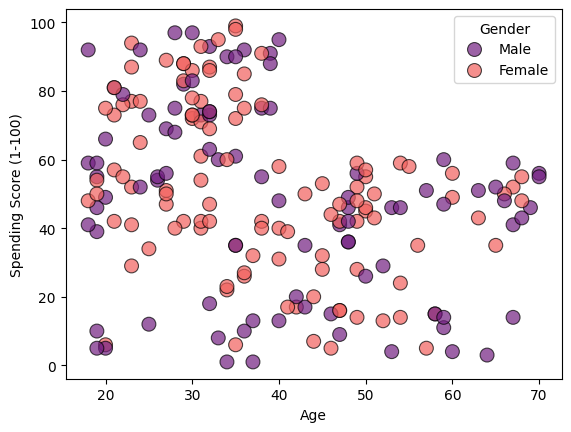

In [12]:
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Gender',
palette='magma', s=100, edgecolor='k', alpha=0.7)

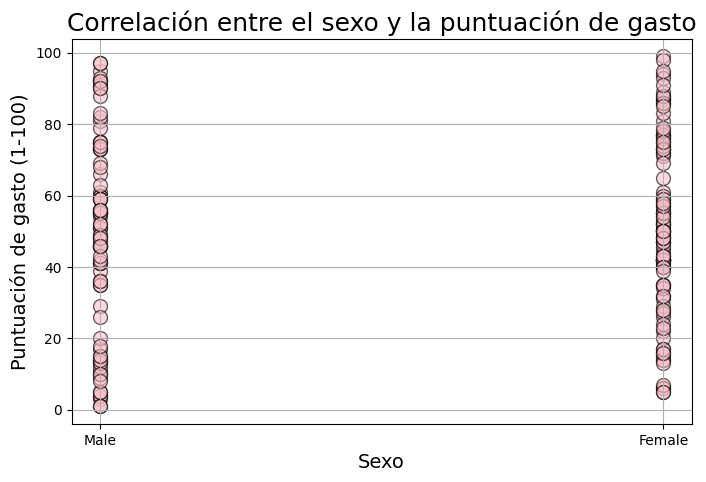

In [13]:
plt.figure(figsize=(8,5))
plt.title("Correlación entre el sexo y la puntuación de gasto", fontsize=18)
plt.xlabel("Sexo", fontsize=14)
plt.ylabel("Puntuación de gasto (1-100)", fontsize=14)
plt.grid(True)
plt.scatter(df['Gender'], df['Spending Score (1-100)'], color='pink', edgecolor='k', alpha=0.6, s=100)
plt.show()

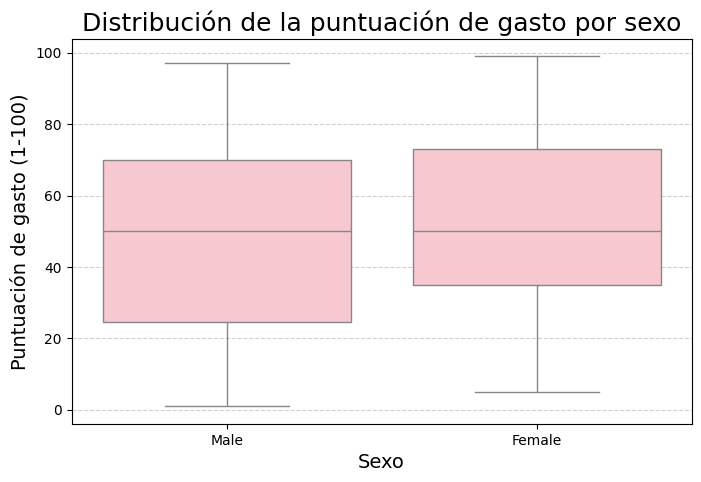

In [14]:

plt.figure(figsize=(8,5))
plt.title("Distribución de la puntuación de gasto por sexo", fontsize=18)
plt.xlabel("Sexo", fontsize=14)
plt.ylabel("Puntuación de gasto (1-100)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

sns.boxplot(x=df['Gender'], y=df['Spending Score (1-100)'], color='pink')

plt.show()

### 4.3. Estrategia

**Por lo tanto, exploraremos agrupar a los clientes en función de sus ingresos anuales y puntuación de gasto para ver si hay grupos distintivos a los que el centro comercial puede dirigirse.**

Podríamos usar K-means pero no tenemos ni idea sobre la cantidad de grupos ocultos. Veremos que el agrupamiento jerárquico con dendogramas nos dará una buena idea del número óptimo de clústeres/agrupamientos.

### 4.4. Dendrogramas

In [15]:
X = df.iloc[:,[3,4]].values

#### 4.4.1. Matriz de distancia _Ward_

En este ejemplo para crear un dendograma no utilizaremos las medidas de distancia entre clústers clásicas (simple, completo, premedio), sino que utilizaremos la matriz de distancia 'Ward'.
$$d(u,v) = \sqrt{\frac{|v|+|s|}{T}d(v,s)^2+ \frac{|v|+|t|}{T}d(v,t)^2- \frac{|v|}{T}d(s,t)^2}$$

donde **$u$** es el clúster recién unido que consta de los clústeres **$s$** y **$t$**, **$v$** es un clúster todavía no utilizado, **$ T=|v|+|s|+|t|$**, y **$|*|$** es la cardinalidad de su argumento. Esto también se conoce como el algoritmo incremental.
El [Criterio de Varianza Mínima de Ward](https://es.wikipedia.org/wiki/M%C3%A9todo_de_Ward) minimiza la varianza total dentro de los clústers. Es decir, minimiza la suma, sobre todos los clusters, de la varianza dentro de cada cluster. En cada paso del algoritmo se debe encontrar el par de clústers que llevan al incremento mínimo de la varianza total dentro de los clústers después de mezclarlos. El par de clústers que al unirse hagan mínima la varianza total dentro de los clúster, son mezclados. En el paso inicial, todos los clúster contienen un punto único (solitario). Para aplicar el algoritmo recursivo bajo esta función objetivo, la distancia inicial entre los objetos individuales debe ser proporcional al cuadrado de la distancia euclídea.

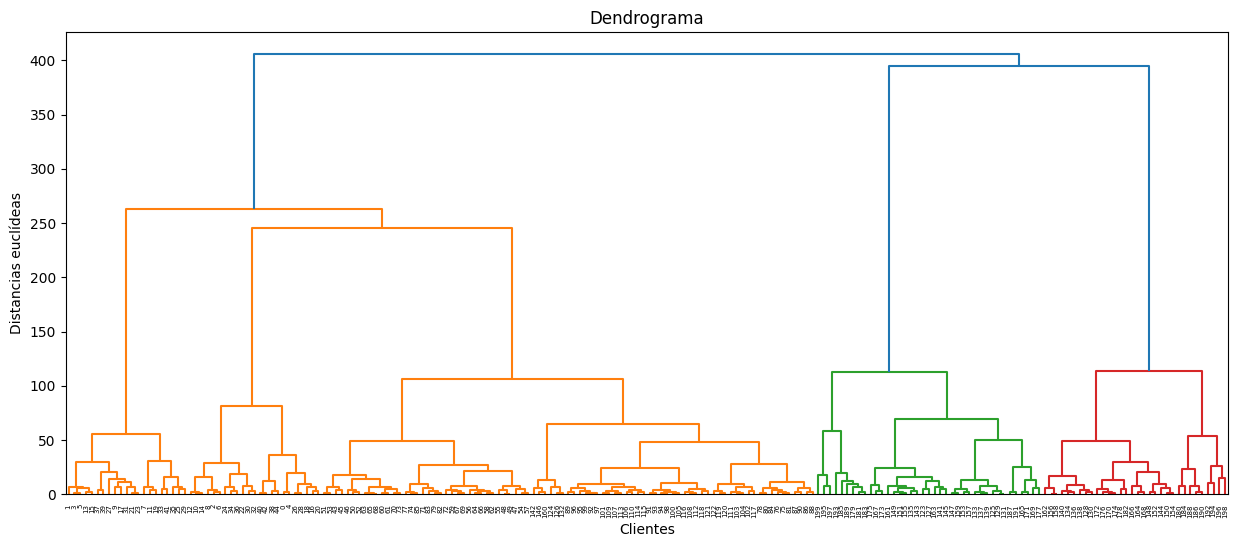

In [16]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15,6))
plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancias euclídeas')
#plt.grid(True)
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.show()

#### 3.4.2. Número óptimo de clústers

A menudo, el número óptimo de grupos se puede encontrar a partir de un dendrograma de una manera sencilla.
* Busca el tramo más largo de la línea vertical que no esté atravesado por ninguna línea horizontal ***extendida*** (aquí *extendida* significa líneas horizontales, es decir, los divisores del grupo se extienden infinitamente en ambas direcciones).
* Ahora en el medio de ese tramo de línea y dibuja una línea horizontal imaginaria.
* Cuenta cuántas líneas verticales cruzaron esas líneas imaginarias.
* Es probable que esa sea la cantidad óptima de clústeres.

**La idea se muestra en la siguiente figura. En este caso, el número óptimo de clústeres podría ser 5.**

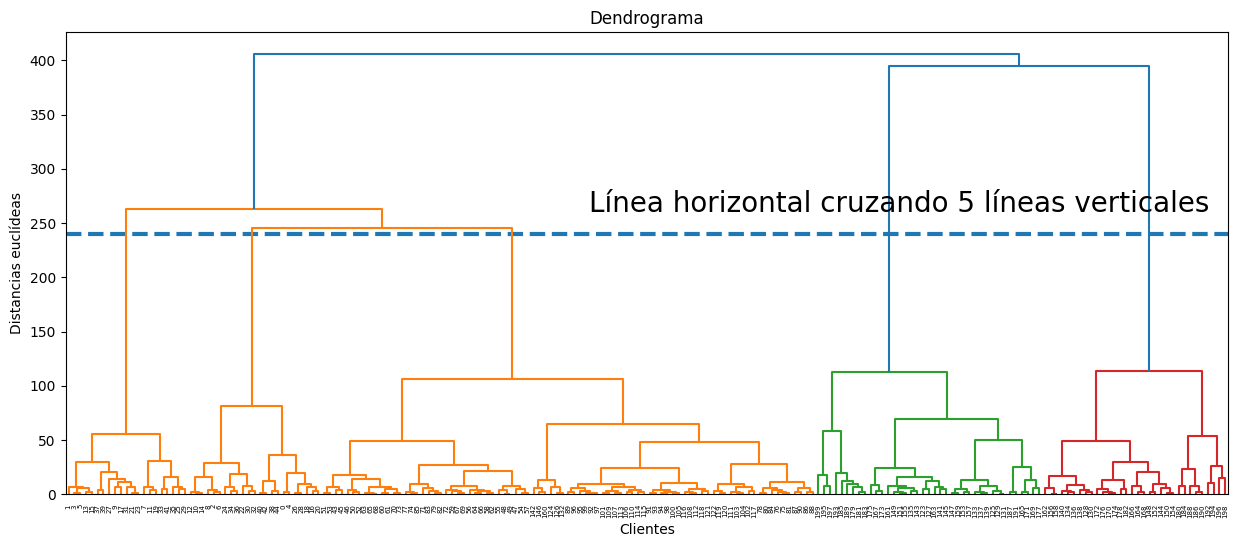

In [17]:
plt.figure(figsize=(15,6))
plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancias euclídeas')
plt.hlines(y=240,xmin=0,xmax=2000,lw=3,linestyles='--')
plt.text(x=900,y=260,s='Línea horizontal cruzando 5 líneas verticales',fontsize=20)
#plt.grid(True)
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.show()

## 3.5. Clustering Jerárquico

### 3.5.1. Creación del modelo

In [18]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, linkage = 'ward')
y_hc = hc.fit_predict(X)

### 3.5.2. Trazado de los grupos y etiquetado de los tipos de clientes
* _Cuidadoso_ - altos ingresos, pero bajos gastos
* _Estándar_: ingresos medios y consumidores medios
* **_Grupo objetivo_: ingresos medio-altos y grandes consumidores (objetivo del centro comercial)**
* _Descuidado_: bajos ingresos, pero grandes consumidores (debe evitarse debido al posible riesgo crediticio)
* _Sensible_ - bajos ingresos y bajos gastos

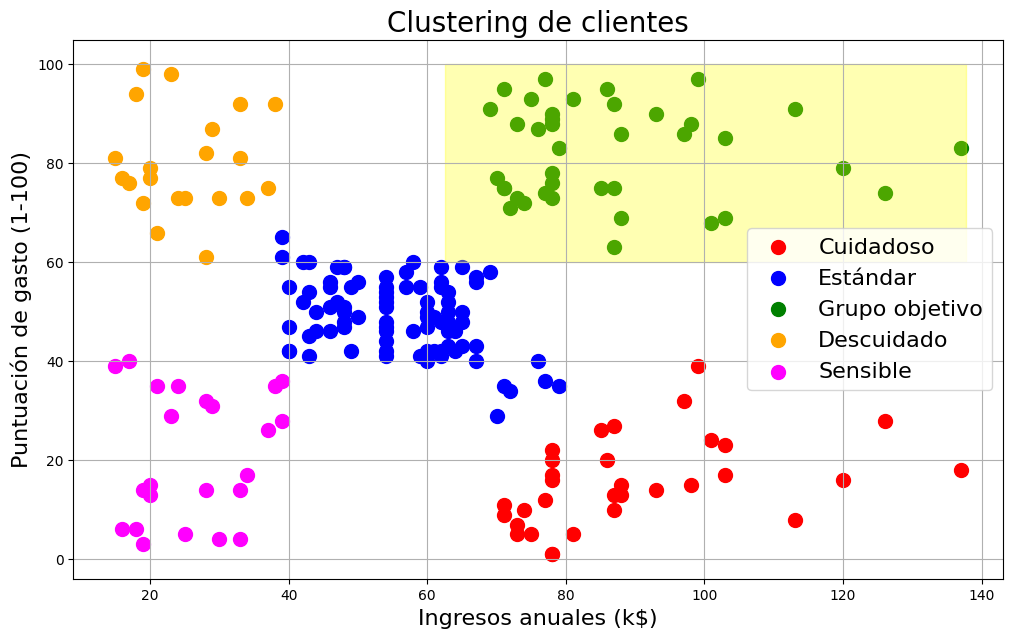

In [19]:
plt.figure(figsize=(12,7))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Cuidadoso')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Estándar')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Grupo objetivo')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'orange', label = 'Descuidado')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Sensible')
plt.title('Clustering de clientes',fontsize=20)
plt.xlabel('Ingresos anuales (k$)',fontsize=16)
plt.ylabel('Puntuación de gasto (1-100)',fontsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.axhspan(ymin=60,ymax=100,xmin=0.4,xmax=0.96,alpha=0.3,color='yellow')
plt.show()

## 3.6. Verificación del número óptimo de clústers por el algoritmo de K-means

Dado un conjunto de observaciones $(x_1, x_2, …, x_n)$, donde cada observación es un vector d-dimensional de valores reales, [**k-means clustering**](https://en.wikipedia.org/wiki/K-means_clustering) pretende particionar las *$n$* observaciones en *$k$* (≤ *$n$*) conjuntos $S = {S_1, S_2, …, S_k}$ para minimizar el suma de los cuadrados intraclúster (WCSS within-clúster sum of squares) (i.e. variance). Formalmente, el objetivo es encontrar:

$${\displaystyle {\underset {\mathbf {S} }{\operatorname {arg\,min} }}\sum _{i=1}^{k}\sum _{\mathbf {x} \in S_{i}}\left\|\mathbf {x} -{\boldsymbol {\mu }}_{i}\right\|^{2}={\underset {\mathbf {S} }{\operatorname {arg\,min} }}\sum _{i=1}^{k}|S_{i}|\operatorname {Var} S_{i}}$$

donde $\mu_i$ es la media de puntos en $S_i$.

Ejecutamos el modelo K-means++ con centroides cuidadosamente inicializados iterando sobre el número de grupos (1 a 15) y mostramos ***la matriz de valores de suma de cuadrados de los clústers (WCSS)*** para determinar el número óptimo de clústers por el método del Elbow.

In [20]:
from sklearn.cluster import KMeans

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


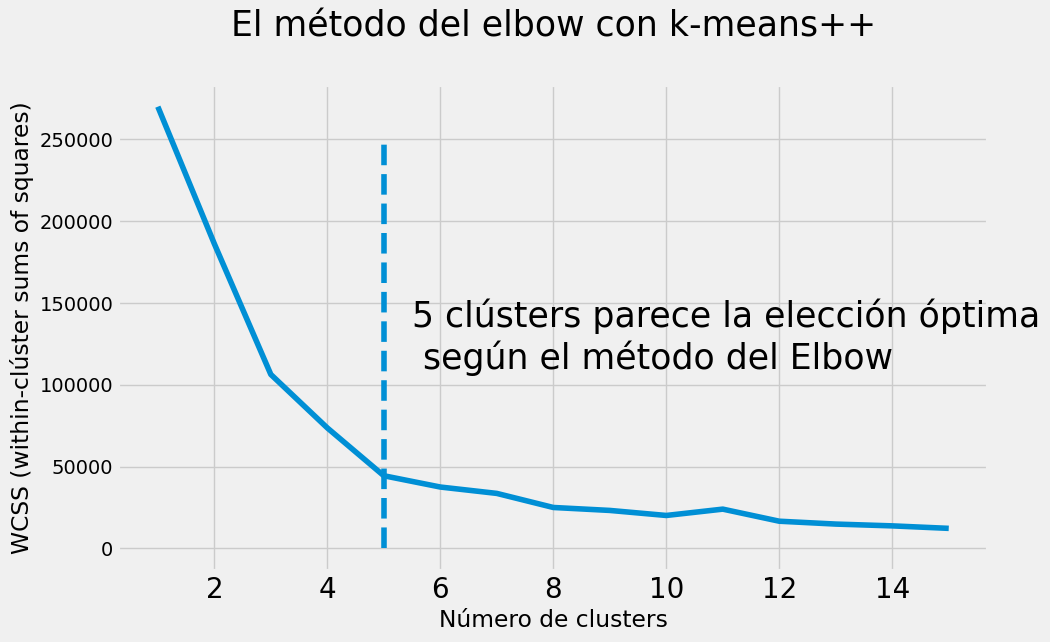

In [21]:
wcss = []
for i in range(1, 16):
    kmeans = KMeans(n_clusters = i, init = 'k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

with plt.style.context(('fivethirtyeight')):
    plt.figure(figsize=(10,6))
    plt.plot(range(1, 16), wcss)
    plt.title('El método del elbow con k-means++\n',fontsize=25)
    plt.xlabel('Número de clusters')
    plt.xticks(fontsize=20)
    plt.ylabel('WCSS (within-clúster sums of squares)')
    plt.vlines(x=5,ymin=0,ymax=250000,linestyles='--')
    plt.text(x=5.5,y=110000,s='5 clústers parece la elección óptima\n según el método del Elbow',
             fontsize=25,fontdict={'family':'Times New Roman'})
    plt.show()

# Ejercicios

Antes de realizar los ejercicios, revisa los conceptos adquiridos durante la sesión leyendo el [pdf del profesor Fernando Berzal](
Clustering-Hierarchical.pdf) sobre esta temática.

**1. Comprueba si según el método del Silhoutte Score el número óptimo de clusteres para este dataset es 5.**

In [22]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [23]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

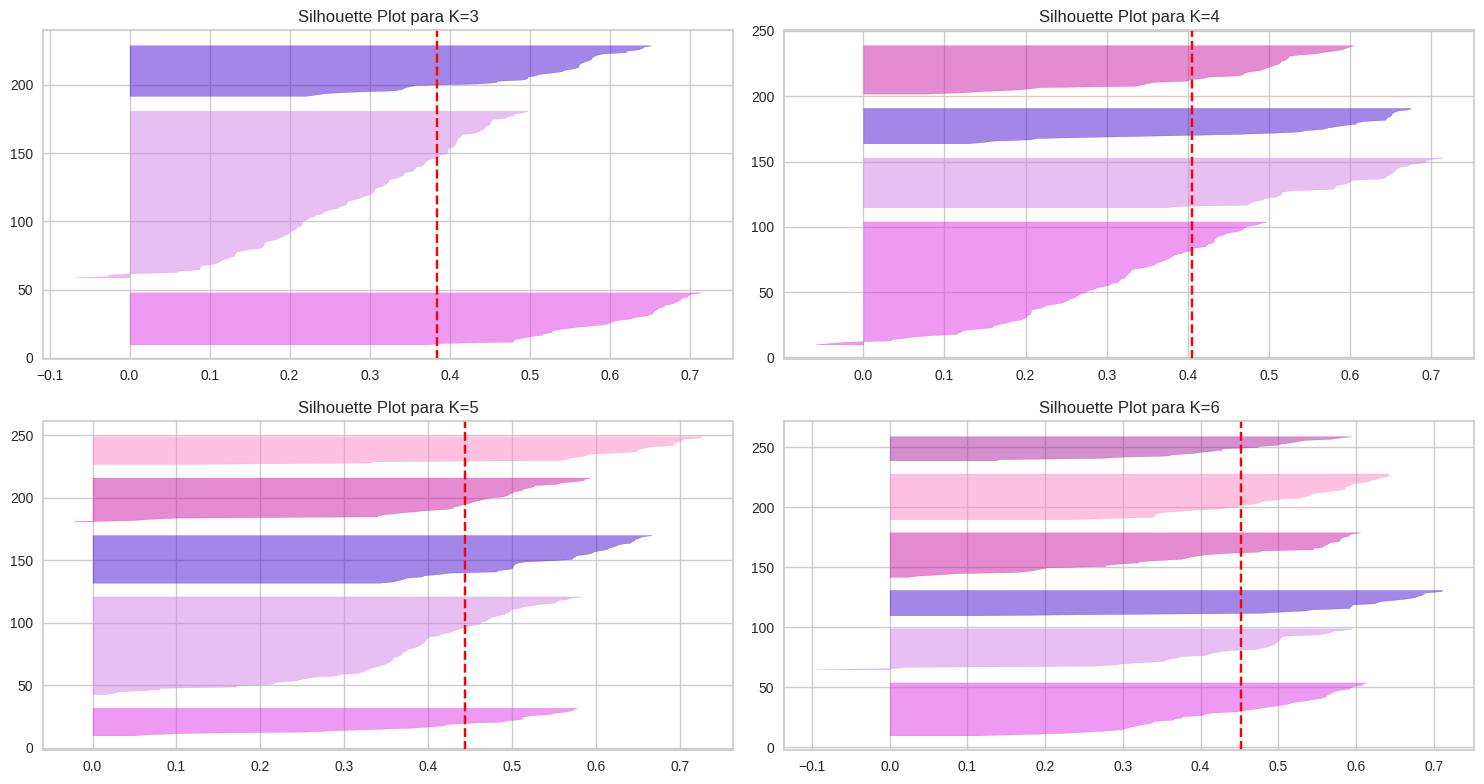

In [24]:


cols_train = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X =df[cols_train]
df = pd.DataFrame(X, columns=cols_train)

fig, ax = plt.subplots(2, 2, figsize=(15,8))

for i in [3, 4, 5, 6]:
    
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    
    q, mod = divmod(i-3, 2)
    
    visualizer = SilhouetteVisualizer(
        km,
        colors=["#de37e7", "#d181e7", "#4811d2", "#cc18a5", '#ff85c1', "#AA20A0"],
        ax=ax[q][mod]
    )
    
    visualizer.fit(X) 
    
    ax[q][mod].set_title(f"Silhouette Plot para K={i}")

plt.tight_layout()
plt.show()

**2. Interpreta la siguiente imagen de un dendrograma y extrae conclusiones. ¿Cuántos clusteres deberían de crearse? ¿Por qué? ¿Qué representan las flechas?**
<img src="img/ejercicio2.png">

Son dos clusters, la flecha representa el ejemplo de esocger cierto puntos del dataset 

**3. ¿Cuales son las principales diferencias entre el algoritmo K-means y el Clustering Jerárquico?**

K-MEANS es un algoritmo iteractivo que buscan unc entroide hsta minimizar ese error
y el otro es aglomerativo va juntando clusters 

En cuanto a clusters jerarquico cuando son datos bastante mas dispersivo, si tengo claro erlrango de clusters 

**4. Toma como base el dataset winequality-red.csv y aplica un algoritmo de clustering jerárquico a dicho dataset considerando las features: pH, alcohol, sulphates y total sulfur dioxide. Responde a las siguientes preguntas: 4.1. ¿Cuál es la media, max, min de dichas características? 4.2. ¿Cuál es la distribución espacial del dataset? Obtén una representación gráfica. 4.3. ¿Cuál es el número óptimo de clústers que obtienes para este dataset? 4.4. Una vez obtenido el valor óptimo de K, genera un modelo AgglomerativeClustering y entrénalo con los datos anteriores- 4.5. Invéntate diversas predicciones para saber en qué clúster se asignan.**

CLUSTERING AGLOMERATIVO: 

In [28]:
df_wine = pd.read_csv('winequality-red.csv', sep=';')
df_wine.head()  

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [34]:
df.isnull().sum()

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [30]:
# Selecciono solo las features q pide???
features = ['pH', 'alcohol', 'sulphates', 'total sulfur dioxide']
df_features = df_wine[features].copy()

In [ ]:
print("--- 4.1. Estadísticas ---")
print(df_features.describe().loc[['mean', 'min', 'max']])

--- 4.1. Estadísticas ---
            pH    alcohol  sulphates  total sulfur dioxide
mean  3.311113  10.422983   0.658149             46.467792
min   2.740000   8.400000   0.330000              6.000000
max   4.010000  14.900000   2.000000            289.000000


In [32]:
# acordarse de escalar!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(X_scaled, columns=features)

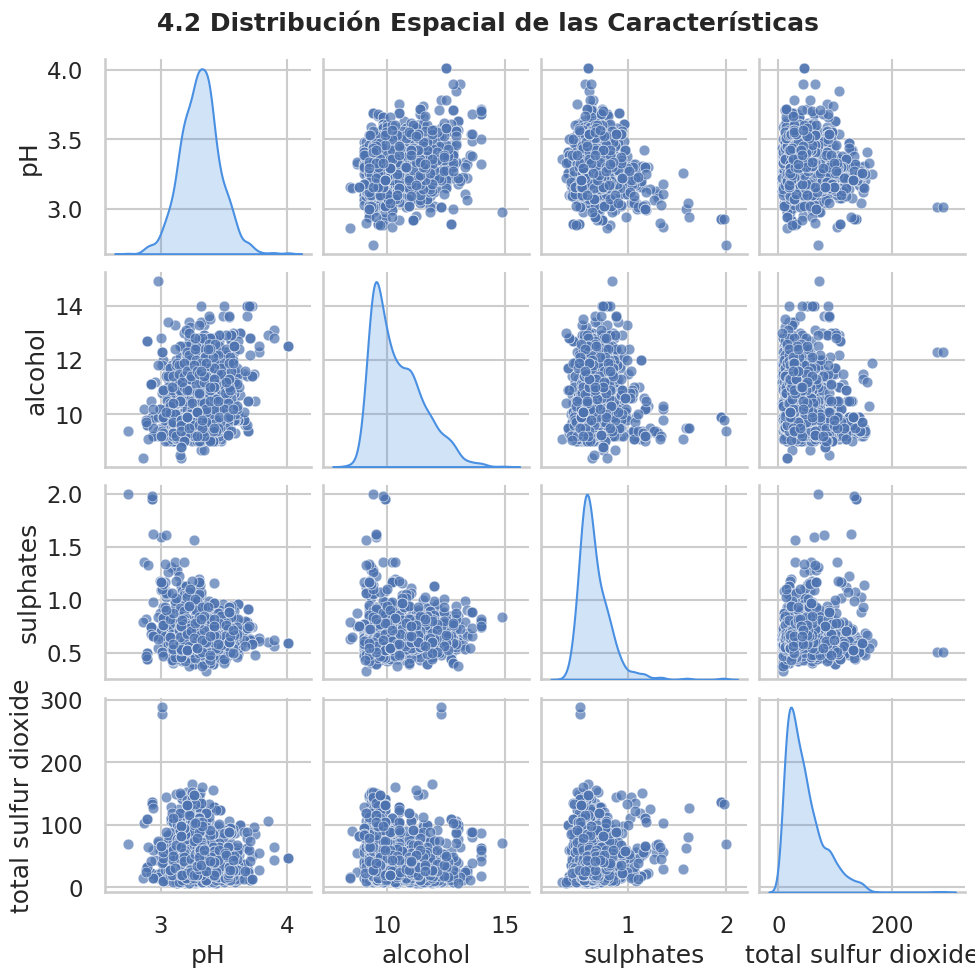

In [33]:

sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("coolwarm", as_cmap=False)

g = sns.pairplot(
    df_features,
    diag_kind="kde",         
    corner=False,           
    plot_kws={
        "alpha": 0.7,         
        "s": 60,              
        "edgecolor": "white",
        "linewidth": 0.5
    },
    diag_kws={
        "fill": True,
        "color": "#4A90E2"
    }
)
g.fig.suptitle(
    "4.2 Distribución Espacial de las Características",
    fontsize=18,
    fontweight="bold"
)

g.fig.subplots_adjust(top=0.93)

plt.show()

La feature de Alcohol la mayoría de los vinos tienen entre 9 y 10 grados, y muy pocos superan los 13. 

pH: casi todos estan entre un rango de 3.3 de pH 



In [36]:
k_optimo = 3 
modelo_jerarquico = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')

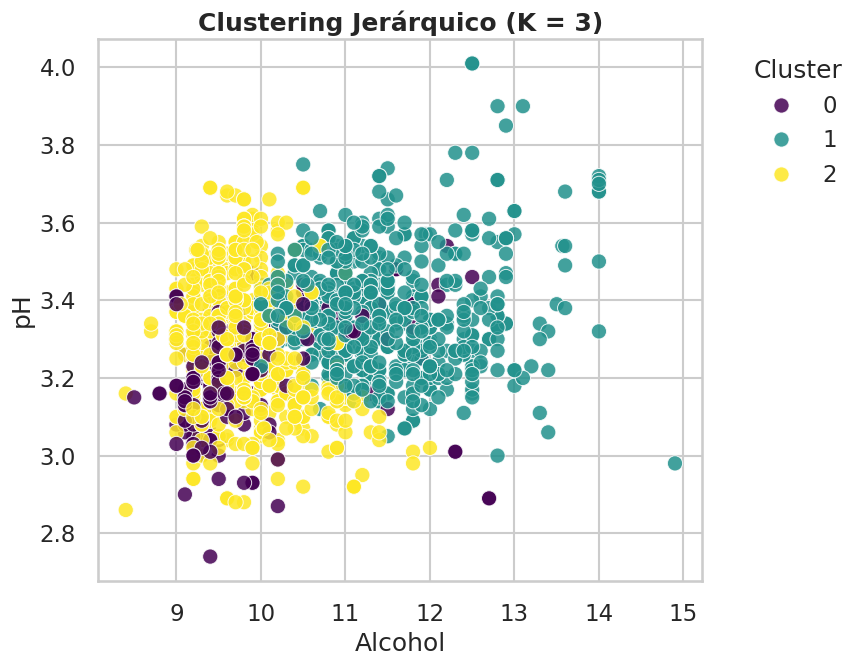

In [39]:
sns.set_theme(style="whitegrid", context="talk")

df_features['Cluster_Jerarquico'] = modelo_jerarquico.fit_predict(df_scaled)

plt.figure(figsize=(9,7))

sns.scatterplot(
    data=df_features,
    x='alcohol',
    y='pH',
    hue='Cluster_Jerarquico',
    palette='viridis',
    s=120,               
    edgecolor='white',    
    linewidth=0.7,
    alpha=0.85
)

plt.title(
    f"Clustering Jerárquico (K = {k_optimo})",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Alcohol")
plt.ylabel("pH")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

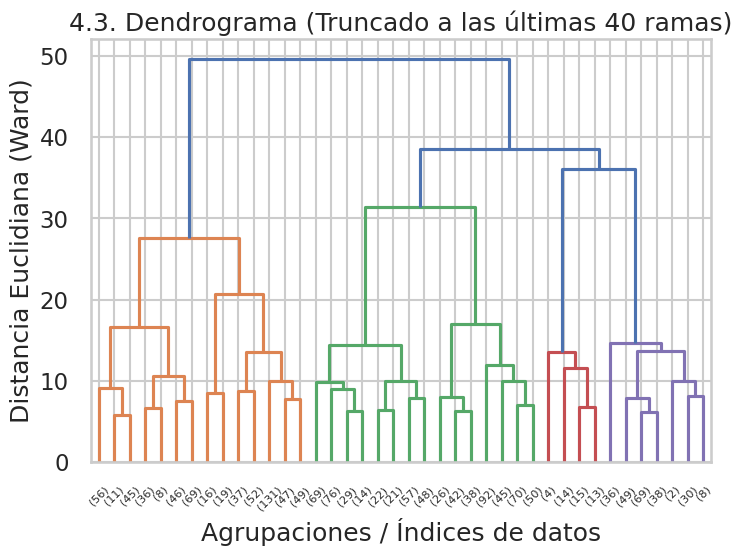

In [50]:
# Dibujamos el dendrograma (truncado para que sea legible si hay muchos datos)
dendrogram = sch.dendrogram(Z, truncate_mode='lastp', p=40)
plt.title('4.3. Dendrograma (Truncado a las últimas 40 ramas)')
plt.xlabel('Agrupaciones / Índices de datos')
plt.ylabel('Distancia Euclidiana (Ward)')
plt.show()

Calcular k se puede hacer de varias formas : 

1. Índice de Calinski-Harabasz (Variance Ratio Criterion)

Es una métrica matemática rapidísima y excelente que viene incluida en Scikit-Learn.

¿Qué mide? 
Calcula la relación (ratio) entre la dispersión que hay fuera de los clústeres (qué tan separados están) y la dispersión dentro de los clústeres (qué tan apretados están).¿Cómo se elige K? Al contrario que el Codo, aquí buscas el número más alto posible.

 Si haces una gráfica, el $K$ óptimo será el pico más alto de la montaña.Ventaja: Es mucho más rápido de calcular que la Silueta, ideal para datasets enormes.

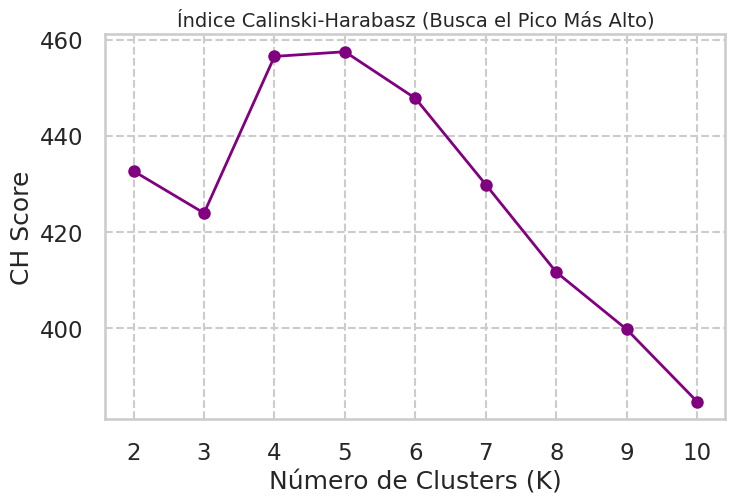

Según Calinski-Harabasz, el K óptimo es: 5


In [44]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ch_scores = []
K_range = range(2, 11)

for k in K_range:
    # Entrenamos el modelo
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(df_scaled) # Usamos los datos escalados
    
    # Calculamos el índice Calinski-Harabasz
    score = calinski_harabasz_score(df_scaled, etiquetas)
    ch_scores.append(score)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(8, 5))
plt.plot(K_range, ch_scores, marker='o', color='purple', linewidth=2)
plt.title('Índice Calinski-Harabasz (Busca el Pico Más Alto)', fontsize=14)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('CH Score')
plt.grid(True, linestyle='--')
plt.show()

# Para imprimir el K ganador automáticamente:
mejor_k_ch = K_range[ch_scores.index(max(ch_scores))]
print(f"Según Calinski-Harabasz, el K óptimo es: {mejor_k_ch}")

-------
2. Estadístico Gap (Gap Statistic) 🌌
Para poder usar este método sin tener que escribir 100 líneas de matemáticas complejas, existe una librería especializada.!!!

Primero, tendrás que instalarla. Crea una celda vacía en tu Jupyter y ejecuta esto:
!pip install gap-stat

Una vez instalada, el código es este:

In [46]:
# # IMPORTANTE: Asegúrate de haber instalado gap-stat primero
# from gap_statistic import OptimalK
# from sklearn.cluster import KMeans
# import numpy as np

# # 1. Configuramos el "calculador" del Gap
# # n_refs=3 (compara con 3 datasets de ruido falso)
# # n_jobs=-1 (usa toda la potencia del procesador)
# optimalK = OptimalK(n_jobs=-1, n_refs=3)

# # 2. Le pasamos los datos (tienen que ser formato numpy array, por eso el .values)
# # Le decimos que pruebe valores de K del 1 al 10
# k_optimo_gap = optimalK(df_scaled.values, cluster_array=np.arange(1, 11))

# print(f"Según el Gap Statistic, el K óptimo es: {k_optimo_gap}")

# # (Opcional) Puedes ver la tabla matemática que ha generado por detrás:
# # display(optimalK.gap_df)

In [41]:
import scipy.cluster.hierarchy as sch
import numpy as np

# 1. Calculamos la matriz de enlace (el árbol)
Z = sch.linkage(df_scaled, method='ward')

# 2. Extraemos las distancias (alturas) a las que ocurren las fusiones
# Z[:, 2] contiene la altura de cada unión en el dendrograma
distancias = Z[:, 2]

# 3. Calculamos la diferencia (salto) entre fusiones consecutivas
saltos = np.diff(distancias)

# 4. Buscamos dónde ocurre el salto más grande
# Le sumamos 2 porque el último salto une 2 clústeres en 1.
k_optimo_matematico = len(distancias) - np.argmax(saltos) + 1

print(f"El cálculo matemático del mayor salto en el dendrograma sugiere: K = {k_optimo_matematico}")

El cálculo matemático del mayor salto en el dendrograma sugiere: K = 3


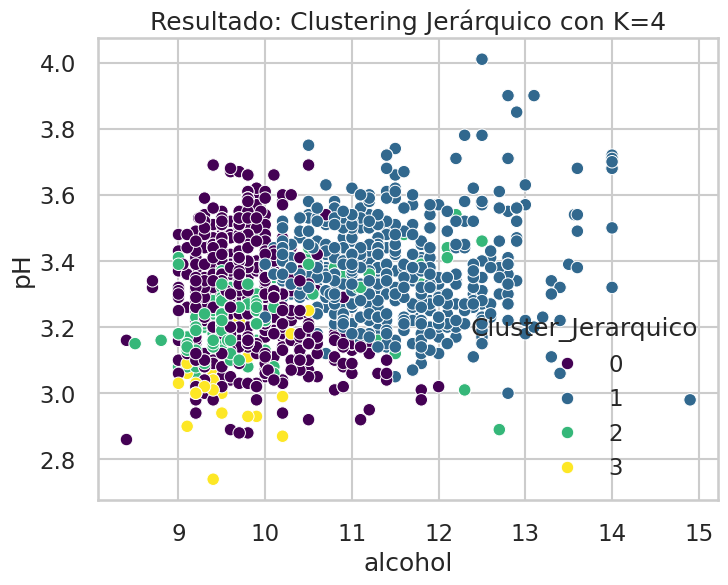

In [51]:
# --- 4.4. MODELO AGGLOMERATIVE CLUSTERING ---
k_optimo = 4
modelo_jerarquico = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')

# Entrenamos y asignamos las etiquetas usando los datos ESCALADOS
df_features['Cluster_Jerarquico'] = modelo_jerarquico.fit_predict(df_scaled)

# (Opcional) Visualizar los clústeres finales usando dos variables
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_features, x='alcohol', y='pH', hue='Cluster_Jerarquico', palette='viridis')
plt.title(f"Resultado: Clustering Jerárquico con K={k_optimo}")
plt.show()

EL JERARQUICO SE CREA, NO ME VALE PARA HACER NUEVA PREDICCION IMAGINATE SALE OTRO PAIS, HABRIA QUE VOLVER ADIESTRAR EL MODELO, NO HACE PREDICCIONES SOLO CLUSTER, K MEANS SI PORQ LO METE POR SIMILITUD SI SE QUIERE VOLVER ELEMENTO HAY QUE VOLVER AHCER EL FIT

EL CLUSTER AGLOMERATIVO , NO DEFINE REGIONES DE CLUSTERS POR LO CUAL NO SE PUEDE HACER PREDICCIONES 

In [ ]:
# --- 4.5. PREDICCIONES INVENTADAS ---
# A diferencia de K-Means, AgglomerativeClustering NO tiene la función .predict()
# Solución: Entrenamos un KNN usando nuestras etiquetas para poder predecir nuevos puntos.
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(df_scaled, df_features['Cluster_Jerarquico'])

# Inventamos 3 vinos con datos aleatorios de [pH, alcohol, sulphates, total sulfur dioxide]
nuevos_vinos = np.array([
    [3.2, 9.5, 0.5, 40],   # Vino 1: Valores bajos
    [3.8, 12.0, 0.9, 10],  # Vino 2: Mucho alcohol, pH alto, muy bajo azufre
    [3.0, 10.5, 1.2, 100]  # Vino 3: Mucho azufre y sulfatos
])

# ¡IMPORTANTE! Escalar los datos nuevos antes de predecir
nuevos_vinos_escalados = scaler.transform(nuevos_vinos)
predicciones = knn.predict(nuevos_vinos_escalados)

print("\n--- 4.5. Predicciones para nuevos vinos ---")
for i, vino in enumerate(nuevos_vinos):
    print(f"Vino Inventado {vino} --> Asignado al Cluster {predicciones[i]}")


--- 4.5. Predicciones para nuevos vinos ---
Vino Inventado [ 3.2  9.5  0.5 40. ] --> Asignado al Cluster 2
Vino Inventado [ 3.8 12.   0.9 10. ] --> Asignado al Cluster 1
Vino Inventado [  3.   10.5   1.2 100. ] --> Asignado al Cluster 0


/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# Webgrafia

[Curso de Tirtjakupto Sarkar](https://github.com/tirthajyoti/Machine-Learning-with-Python)
[Apuntes de Fernando Berzal de la Universidad de Granada](https://elvex.ugr.es/idbis/dm/slides/42%20Clustering%20-%20Hierarchical.pdf)
Curso de la Xunta de Galicia impartido por Alfonso Antolínez
[DataCamp](https://www.datacamp.com/)

# Licencia

[Attributon-ShacerAlike 4.0 International](https://creativecommons.org/licenses/by-sa/4.0/)

Puedes utilizar libremente este material, con las siguientes condiciones:

* Atribuir la autoría a este documento.
* Si lo utilizas y haces cambios, deberás liberarlo también bajo la misma licencia.